# Dataset + DataLoader demo (subsampling)

This notebook shows how to:
- Build a PDE dataset via `PDEDataset(cfg, build_fn)`
- Use `torch.utils.data.DataLoader(..., shuffle=True)` as the subsampling mechanism
- Run a small demo training loop (inline, no helper training functions)

Note: the `prog/` modules require Python \>= 3.9.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader

# Make repo root importable
REPO_ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebook" else Path.cwd().resolve()
sys.path.insert(0, str(REPO_ROOT))

from Datasets.Datasets import PDEDataset
from Datasets.data.processed.burg_gen.burg_gen import BurgersDatasetConfig, build_dataset_from_burgers

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [55]:
# Dataset config (these control the solver + sampling)
cfg = BurgersDatasetConfig(
    N=256,
    L=2 * np.pi,
    nu=0.02,
    dt=2e-3,
    T=1.0,
    seed=1432,
    noise_level=0.05,
    stride_t=5,
    stride_x=5,
)

# Optional: fixed-size subset view (DataLoader will shuffle within this subset)
cfg.subset_size = 800
cfg.subset_seed = 0

dataset = PDEDataset(cfg, build_dataset_from_burgers)
len(dataset), len(dataset.full_dataset)

(800, 2652)

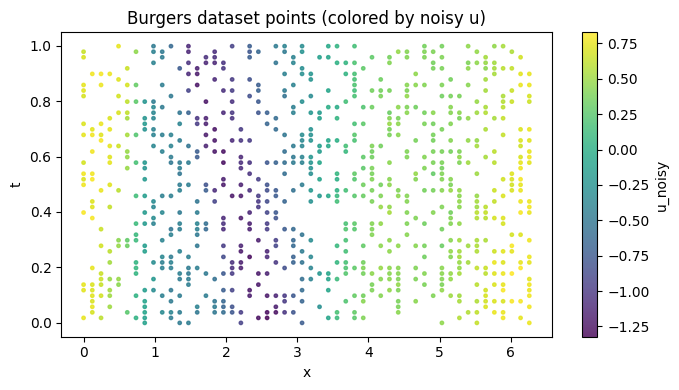

In [56]:
# Plot the full dataset (downsampled for visualization)
t_all, x_all, y_all, y_noisy_all = dataset.full()
idx = dataset.subset_indices
t_plot = t_all[idx].numpy()
x_plot = x_all[idx].numpy()
y_plot = y_noisy_all[idx].numpy()

plt.figure(figsize=(7, 4))
plt.scatter(x_plot, t_plot, c=y_plot, s=6, cmap="viridis", alpha=0.8)
plt.xlabel("x")
plt.ylabel("t")
plt.title("Burgers dataset points (colored by noisy u)")
plt.colorbar(label="u_noisy")
plt.tight_layout()
plt.show()

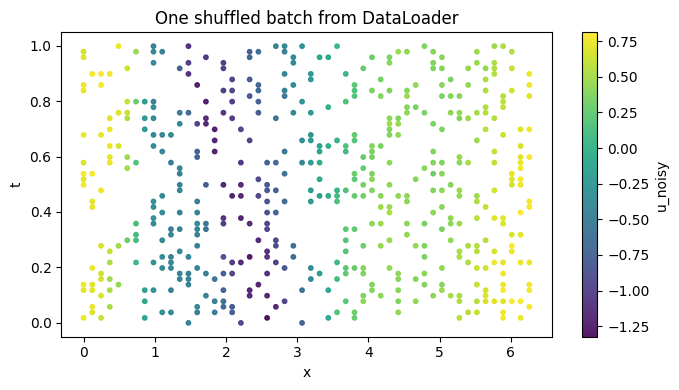

In [58]:
# DataLoader subsampling: shuffle=True gives different batches each epoch
loader = DataLoader(
    dataset,
    batch_size=500,
    shuffle=True,
)

t_b, x_b, y_clean_b, y_noisy_b = next(iter(loader))

plt.figure(figsize=(7, 4))
plt.scatter(x_b.numpy(), t_b.numpy(), c=y_noisy_b.numpy(), s=10, cmap="viridis", alpha=0.9)
plt.xlabel("x")
plt.ylabel("t")
plt.title("One shuffled batch from DataLoader")
plt.colorbar(label="u_noisy")
plt.tight_layout()
plt.show()

In [ ]:
# Demo training loop (inline)
from prog import featlib, mlps, trainer

selected_derivs = ("u", "u_x", "u_xx")

u_model = mlps.SimpleMLP(n_layers=4, hidden_size=64, act=mlps.Sin)
v_model = mlps.EQL(in_dim=len(selected_derivs), prod_dim=2, num_layers=1, bias=False)

cfg_t = trainer.TrainerConfig(
    lr=1e-3,
    lambda_pde=0.5,
    lambda_reg=0.0,
    lambda_tv=0.0,
    lambda_data=10.0,
    selected_derivs=selected_derivs,
    device=device,
)

ft = featlib.FeatureTensor(selected_derivs, normalize=False)
tr = trainer.PDETrainer(u_model=u_model, v_model=v_model, cfg=cfg_t, feature_builder=ft.build)

u_model.to(device)
v_model.to(device)

steps = 200
batch_size = 1024
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
loader_iter = iter(loader)

history = []
for step in range(steps):
    try:
        t, x, y_clean, y_noisy = next(loader_iter)
    except StopIteration:
        loader_iter = iter(loader)
        t, x, y_clean, y_noisy = next(loader_iter)

    out = tr.step(t=t, x=x, u_noisy=y_noisy, u_clean=y_clean)
    history.append(
        {
            "step": step,
            "total_loss": float(out["loss"]),
            "data_loss": float(out["loss_data"]),
            "pde_loss": float(out["loss_pde"]),
            "tv_loss": float(out["loss_tv"]),
            "l1_loss": float(out["l1"]),
        }
    )

    if step % 25 == 0:
        print(
            f"step={step:4d} total={history[-1]['total_loss']:.4e} "
            f"data={history[-1]['data_loss']:.4e} pde={history[-1]['pde_loss']:.4e}"
        )

history[:2], history[-1]

step=   0 total=3.4026e+00 data=3.4023e-01 pde=5.5713e-04
step=  25 total=1.0097e+00 data=9.8039e-02 pde=5.8644e-02
step=  50 total=4.0245e-01 data=3.3492e-02 pde=1.3505e-01
step=  75 total=3.3675e-01 data=2.9496e-02 pde=8.3575e-02
step= 100 total=2.9287e-01 data=2.5362e-02 pde=7.8503e-02
step= 125 total=2.5851e-01 data=2.2650e-02 pde=6.4019e-02
step= 150 total=2.2801e-01 data=2.0113e-02 pde=5.3751e-02
step= 175 total=2.0575e-01 data=1.8210e-02 pde=4.7301e-02


([{'step': 0,
   'total_loss': 3.402594804763794,
   'data_loss': 0.34023162722587585,
   'pde_loss': 0.000557125371415168,
   'tv_loss': 0.0,
   'l1_loss': 3.3009209632873535},
  {'step': 1,
   'total_loss': 2.8766300678253174,
   'data_loss': 0.28754329681396484,
   'pde_loss': 0.002394069917500019,
   'tv_loss': 0.0,
   'l1_loss': 3.3047287464141846}],
 {'step': 199,
  'total_loss': 0.19224141538143158,
  'data_loss': 0.017224475741386414,
  'pde_loss': 0.03999330848455429,
  'tv_loss': 0.0,
  'l1_loss': 3.7424535751342773})

In [ ]:
# Plot losses
steps_arr = np.array([r["step"] for r in history])
total = np.array([r["total_loss"] for r in history])
data = np.array([r["data_loss"] for r in history])
pde = np.array([r["pde_loss"] for r in history])

plt.figure(figsize=(7, 4))
plt.plot(steps_arr, total, label="total")
plt.plot(steps_arr, data, label="data")
plt.plot(steps_arr, pde, label="pde")
plt.yscale("log")
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Demo training losses")
plt.legend()
plt.tight_layout()
plt.show()